<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.981 · TFM · Aula 1</p>
<p style="margin: 0; text-align:right;">2024-2 · Màster universitari en Ciència de dades (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudis d'informàtica, multimèdia i telecomunicació</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>
<div style="text-align: center; margin-top: 40px;">
    <h1>Aplicación para ayuda a la conducción con deep learning</h1>
</div>

### ARCHIVO 14: Programa principal main

Código que evalua vídeos e imágenes con los modelos previamente entrenados y en función de parámetros archivo config.

Código ejecutado en plataforma Visual Studio Code.

In [1]:
# Llibreries

from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
import yaml
import torch.nn.functional as F
from PIL import Image

In [2]:
#Càrrega de paràmetres

# Arxiu Configuració
with open("config.yaml", "r") as file:
    config = yaml.safe_load(file)

#Funcionalitat
vehicles = config['functionality']['vehicles']
signs = config['functionality']['signs']
use_gpu = config['functionality']['use_gpu']

# Selecció de dispositiu
device = torch.device('cuda' if use_gpu and torch.cuda.is_available() else 'cpu')

# Models
if vehicles:
    model_veh = YOLO(config['model_paths']['detect_vehicles'])                             # Model detecció turismes i motos
    model_seg = YOLO(config['model_paths']['car_segment'])                                 # Model segmentació cotxes
    model_bra = torch.load(config['model_paths']['brake_classifier'], map_location=device) # Model classificació frens
    model_bra = model_bra.to(device).eval()        
        
    # Transformació per model_bra
    transform_frens = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224, 224)),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
                            ])

if signs:
    model_sin = YOLO(config['model_paths']['traffic_signs'])                             # Model detecció de semàfors i stops
    model_sem = torch.load(config['model_paths']['traffic_lights'], map_location=device) # Model classificació de semàfors
    model_sem = model_sem.to(device).eval()    
        
    # Transformació per model_sem
    transform_semafor = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
                            ])
    
# Paràmetres
# Models
det_veh_conf = config['model_det_veh_param']['det_veh_conf']
det_veh_iou = config['model_det_veh_param']['det_veh_iou']
det_sig_conf = config['model_det_sig_param']['det_sig_conf']
det_sig_iou = config['model_det_sig_param']['det_sig_iou']
seg_car_conf = config['model_seg_car_param']['seg_car_conf']
seg_car_iou = config['model_seg_car_param']['seg_car_iou']
class_brake = config['model_cla_bra_param']['class_brake']
# Alarma
height_max = config['set_up_vehicle']['height']
x_position = config['set_up_vehicle']['x_position']

In [3]:
# Entrada

picture = None
video = None

try:
    picture = cv2.imread(config['input']['picture'])
except Exception as e:
    print("No s'ha pogut carregar la imatge")
    
try:
    video = cv2.VideoCapture(config['input']['video'])
    if not video.isOpened():
        raise FileNotFoundError("No s'ha pogut obrir el vídeo.")
except Exception as e:
    print("No s'ha pogut carregar el vídeo")
    
pic = picture is not None
vid = video is not None

No s'ha pogut carregar el vídeo



0: 480x640 7 cars, 1 motorcycle, 41.2ms
Speed: 5.9ms preprocess, 41.2ms inference, 4.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 traffic lights, 14.3ms
Speed: 3.3ms preprocess, 14.3ms inference, 2.4ms postprocess per image at shape (1, 3, 480, 640)


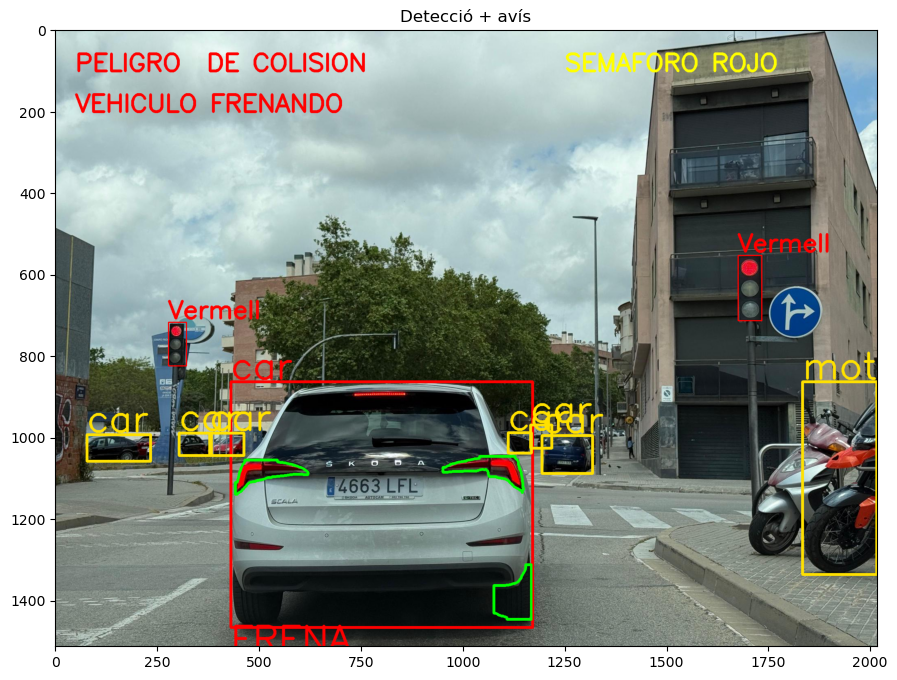

In [ ]:
# Imatge
if pic:
    
    frame = picture
        
    # Vehicles
    if vehicles:
        
        # Detecció
        r_det_veh = model_veh(frame, conf=det_veh_conf, iou=det_veh_iou)[0]

        for box in r_det_veh.boxes:

            cls = int(box.cls[0])
            label = model_veh.names[cls]
            conf = box.conf[0]

            # Coordenades
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            x1, y1 = max(x1, 0), max(y1, 0)
            x2, y2 = min(x2, frame.shape[1]), min(y2, frame.shape[0])

            # Perill de col·lisió - Terç central? i Alçada bbox > 22%?
            width = frame.shape[1]
            height = frame.shape[0]

            center_x = (x1 + x2) / 2
            bbox_height = y2 - y1

            left_third = width/2 - (x_position * width / 2)
            right_third = width/2 + (x_position * width / 2)

            # Comprovació de perill
            perill = left_third <= center_x <= right_third and bbox_height > height_max * height

            if perill:
                cv2.putText(frame, "PELIGRO  DE COLISION", (50, 100), # Missatge de perill per col·lisió
                    cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 5)

            # Color de la bbox
            color = (0, 0, 255) if perill else (0, 225, 255)  # Vermell si perill, sinó groc

            
            # Dibuix bbox i text
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 5)
            label_text = f"{label}"
            cv2.putText(frame, label_text, (x1, y1 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 3, color, 5)
   
            # Segmentació
            roi = frame[y1:y2, x1:x2]
            r_car_seg = model_seg(roi, conf=seg_car_conf, iou=seg_car_iou, verbose=False)[0]

            if r_car_seg.masks is not None and left_third <= center_x <= right_third: # Si segmenta, es mostren els resultats
                for i, mask in enumerate(r_car_seg.masks.data):
                    if i == 4 or i == 7 or i == 5:
                        mask_np = mask.cpu().numpy().astype("uint8") * 255
                        mask_resized = cv2.resize(mask_np, (x2 - x1, y2 - y1))

                        # Contorn
                        contours, _ = cv2.findContours(mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                        cv2.drawContours(roi, contours, -1, (0, 255, 0), 5) # Verd

                        # Retalla part segmentada
                        seg_img = roi.copy()
                        seg_img[mask_resized == 0] = 0

                        # Prepara per inferència
                        input_img = cv2.cvtColor(seg_img, cv2.COLOR_BGR2RGB)
                        input_img = cv2.resize(input_img, (224, 224))
                        input_tensor = transform_frens(input_img).unsqueeze(0).to(device)

                        with torch.no_grad():
                            output = model_bra(input_tensor)
                            prob = torch.sigmoid(output).item()
                            frenada = prob > config['model_cla_bra_param']['class_brake']

                        # Mostra resultat
                        status_text = "FRENA" if frenada else ""
                        color = (0, 0, 255) if frenada else (0, 255, 255)
                        cv2.putText(frame, status_text, (x1, y2 + 60),
                                    cv2.FONT_HERSHEY_SIMPLEX, 3, color, 6, cv2.LINE_AA)
                        if frenada:
                            cv2.putText(frame, "VEHICULO FRENANDO", (50, 200), # Missatge de frenada
                                cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 5)
                            
    # Semàfors i stops
    if signs:

        criticitat = 0
        stop = False

        # Detecció
        r_det_sin = model_sin(frame, conf=det_sig_conf, iou=det_sig_iou)[0]

        # Noms de classes
        class_names = ["Scrap", "Verd", "Ignorar", "Vermell", "Groc"]


        for box in r_det_sin.boxes:

            cls = int(box.cls[0])
            conf = float(box.conf[0])
            
            # Coordenades
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            x1, y1 = max(x1, 0), max(y1, 0)
            x2, y2 = min(x2, frame.shape[1]), min(y2, frame.shape[0])

            roi = frame[y1:y2, x1:x2]

            if cls == 1: # stop
                stop = True

            if cls == 0: # semàfor
                # Classificació amb EfficientNet
                img_pil = Image.fromarray(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
                input_tensor = transform_semafor(img_pil).unsqueeze(0).to(device)

                with torch.no_grad():
                    output = model_sem(input_tensor)
                    probs = F.softmax(output, dim=1)
                    confidence, pred = torch.max(probs, dim=1)
                    confidence = confidence.item()
                    pred = pred.item()

                # Color semàfor
                if pred == 0:
                    color_sem = (0, 0, 0)
                elif pred == 1:
                    color_sem = (0, 255, 0)
                elif pred == 2:
                    color_sem = (0, 0, 0)
                elif pred == 3:
                    color_sem = (0, 0, 255)
                    criticitat = 3
                else:
                    color_sem = (0, 255, 255)

                # Pitjor cas semàfor
                if pred == 3: # Vermell
                    criticitat = 3
                elif pred == 4 and criticitat < 3: # Groc
                    criticitat = 4                   

                # Mostra resultat
                if pred > 0:
                    cv2.rectangle(frame, (x1, y1), (x2, y2), color_sem, 2)
                    cv2.putText(frame, class_names[pred], (x1, y1 - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 2, color_sem, 5)

        missatge = "SEMAFORO AMBAR" if criticitat == 4 else "SEMAFORO ROJO"           
        if criticitat > 2:
            cv2.putText(frame, missatge, (1250, 100), # Missatge de semàfor
                cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 255), 5) 

        if stop:
            cv2.putText(frame, "STOP VISIBLE", (1250, 200), # Missatge stop
                cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 255), 5)                
                                       
    # Correcció BGR a RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Mostra la imatge
    plt.figure(figsize=(12, 8))
    plt.imshow(frame_rgb)
    plt.title("Detecció + avís")
    plt.show()

In [ ]:
# Video
if vid:

    #cap = video
    cap = cv2.VideoCapture("Media/v2.mp4")

    # Sortida
    out = cv2.VideoWriter("v2out.mp4",
                        cv2.VideoWriter_fourcc(*'mp4v'),
                        cap.get(cv2.CAP_PROP_FPS),
                        (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))
    
    # Per fotograma
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

    
        
        # Vehicles
        if vehicles:
            
            # Detecció
            r_det_veh = model_veh(frame, conf=det_veh_conf, iou=det_veh_iou)[0]

            for box in r_det_veh.boxes:

                cls = int(box.cls[0])
                label = model_veh.names[cls]
                conf = box.conf[0]

                # Coordenades
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                x1, y1 = max(x1, 0), max(y1, 0)
                x2, y2 = min(x2, frame.shape[1]), min(y2, frame.shape[0])

                # Perill de col·lisió - Terç central? i Alçada bbox > 22%?
                width = frame.shape[1]
                height = frame.shape[0]

                center_x = (x1 + x2) / 2
                bbox_height = y2 - y1

                left_third = width/2 - (x_position * width / 2)
                right_third = width/2 + (x_position * width / 2)

                # Comprovació de perill
                perill = left_third <= center_x <= right_third and bbox_height > height_max * height

                if perill:
                    cv2.putText(frame, "PELIGRO  DE COLISION", (50, 100), # Missatge de perill per col·lisió
                        cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 5)

                # Color de la bbox
                color = (0, 0, 255) if perill else (0, 225, 255)  # Vermell si perill, sinó groc

                
                # Dibuix bbox i text
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 5)
                label_text = f"{label}"
                cv2.putText(frame, label_text, (x1, y1 - 8),
                            cv2.FONT_HERSHEY_SIMPLEX, 3, color, 5)
    
                # Segmentació
                roi = frame[y1:y2, x1:x2]
                r_car_seg = model_seg(roi, conf=seg_car_conf, iou=seg_car_iou, verbose=False)[0]

                if r_car_seg.masks is not None and left_third <= center_x <= right_third: # Si segmenta, es mostren els resultats
                    for i, mask in enumerate(r_car_seg.masks.data):
                        if i == 4 or i == 7 or i == 5:
                            mask_np = mask.cpu().numpy().astype("uint8") * 255
                            mask_resized = cv2.resize(mask_np, (x2 - x1, y2 - y1))

                            # Contorn
                            contours, _ = cv2.findContours(mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                            cv2.drawContours(roi, contours, -1, (0, 255, 0), 5) # Verd

                            # Retalla part segmentada
                            seg_img = roi.copy()
                            seg_img[mask_resized == 0] = 0

                            # Prepara per inferència
                            input_img = cv2.cvtColor(seg_img, cv2.COLOR_BGR2RGB)
                            input_img = cv2.resize(input_img, (224, 224))
                            input_tensor = transform_frens(input_img).unsqueeze(0).to(device)

                            with torch.no_grad():
                                output = model_bra(input_tensor)
                                prob = torch.sigmoid(output).item()
                                frenada = prob > config['model_cla_bra_param']['class_brake']

                            # Mostra resultat
                            status_text = "FRENA" if frenada else ""
                            color = (0, 0, 255) if frenada else (0, 255, 255)
                            cv2.putText(frame, status_text, (x1, y2 + 60),
                                        cv2.FONT_HERSHEY_SIMPLEX, 3, color, 6, cv2.LINE_AA)
                            if frenada:
                                cv2.putText(frame, "VEHICULO FRENANDO", (50, 200), # Missatge de frenada
                                    cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 5)
                                
        # Semàfors i stops
        if signs:

            criticitat = 0
            stop = False

            # Detecció
            r_det_sin = model_sin(frame, conf=det_sig_conf, iou=det_sig_iou)[0]

            # Noms de classes
            class_names = ["Scrap", "Verd", "Ignorar", "Vermell", "Groc"]


            for box in r_det_sin.boxes:

                cls = int(box.cls[0])
                conf = float(box.conf[0])
                
                # Coordenades
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                x1, y1 = max(x1, 0), max(y1, 0)
                x2, y2 = min(x2, frame.shape[1]), min(y2, frame.shape[0])

                roi = frame[y1:y2, x1:x2]

                if cls == 1: # stop
                    stop = True

                if cls == 0: # semàfor
                    # Classificació amb EfficientNet
                    img_pil = Image.fromarray(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
                    input_tensor = transform_semafor(img_pil).unsqueeze(0).to(device)

                    with torch.no_grad():
                        output = model_sem(input_tensor)
                        probs = F.softmax(output, dim=1)
                        confidence, pred = torch.max(probs, dim=1)
                        confidence = confidence.item()
                        pred = pred.item()

                    # Color semàfor
                    if pred == 0:
                        color_sem = (0, 0, 0)
                    elif pred == 1:
                        color_sem = (0, 255, 0)
                    elif pred == 2:
                        color_sem = (0, 0, 0)
                    elif pred == 3:
                        color_sem = (0, 0, 255)
                        criticitat = 3
                    else:
                        color_sem = (0, 255, 255)

                    # Pitjor cas semàfor
                    if pred == 3: # Vermell
                        criticitat = 3
                    elif pred == 4 and criticitat < 3: # Groc
                        criticitat = 4                   

                    # Mostra resultat
                    if pred > 0:
                        cv2.rectangle(frame, (x1, y1), (x2, y2), color_sem, 2)
                        cv2.putText(frame, class_names[pred], (x1, y1 - 10),
                                    cv2.FONT_HERSHEY_SIMPLEX, 2, color_sem, 5)

            missatge = "SEMAFORO AMBAR" if criticitat == 4 else "SEMAFORO ROJO"           
            if criticitat > 2:
                cv2.putText(frame, missatge, (1250, 100), # Missatge de semàfor
                    cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 255), 5) 

            if stop:
                cv2.putText(frame, "STOP VISIBLE", (1250, 200), # Missatge stop
                    cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 255), 5)                
                                        
        # Correcció BGR a RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Escriu el frame al vídeo sortida
        out.write(frame)

# Tanca arxiu
cap.release()
out.release()
#cv2.destroyAllWindows()


0: 384x640 (no detections), 125.5ms
Speed: 9.2ms preprocess, 125.5ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 96.9ms
Speed: 4.1ms preprocess, 96.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 16.1ms
Speed: 2.9ms preprocess, 16.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 traffic light, 17.6ms
Speed: 3.2ms preprocess, 17.6ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 18.1ms
Speed: 3.5ms preprocess, 18.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 19.1ms
Speed: 2.8ms preprocess, 19.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 15.3ms
Speed: 2.8ms preprocess, 15.3ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 20.9ms
Speed: 2.7ms preprocess, 20.9ms inferenc